<a href="https://colab.research.google.com/github/kutayeroglu/biomimetic-training/blob/main/interpret_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import ast
import os

# Define the path to your results
file_path = "/content/drive/MyDrive/colab_results/biomimetic_training/evaluation_results.csv"

if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
else:
    # 1. Load the data
    df = pd.read_csv(file_path, index_col=0)

    # 2. Function to parse the string "[shape, other, texture]" into a list of integers
    def parse_results(val):
        return ast.literal_eval(val)

    # 3. Focus on the baseline (no ablation) for both ranking methods
    baseline_cols = [col for col in df.columns if "ablation_0" in col]

    print(f"Verifying baseline claims for: {baseline_cols}\n")

    for col in baseline_cols:
        # Convert strings to lists
        parsed_data = df[col].apply(parse_results)

        # Calculate totals
        total_shape = sum([x[0] for x in parsed_data])
        total_other = sum([x[1] for x in parsed_data])
        total_texture = sum([x[2] for x in parsed_data])
        total_images = total_shape + total_other + total_texture

        # Calculate bias metrics
        # Shape bias is defined as shape / (shape + texture)
        denominator = total_shape + total_texture
        shape_bias = (total_shape / denominator) if denominator > 0 else 0
        texture_bias = (total_texture / denominator) if denominator > 0 else 0

        print(f"--- Results for {col} ---")
        print(f"Total Images Analyzed: {total_images}")
        print(f"Shape-consistent decisions: {total_shape}")
        print(f"Texture-consistent decisions: {total_texture}")
        print(f"Other/Incorrect decisions: {total_other}")
        print(f"Calculated Shape Bias: {shape_bias:.4f}")
        print(f"Calculated Texture Bias: {texture_bias:.4f}\n")

Verifying baseline claims for: ['color_standard_alexnet_ablation_0', 'fft_freq_standard_alexnet_ablation_0', 'color_reverse_standard_alexnet_ablation_0', 'fft_freq_reverse_standard_alexnet_ablation_0']

--- Results for color_standard_alexnet_ablation_0 ---
Total Images Analyzed: 1200
Shape-consistent decisions: 66
Texture-consistent decisions: 111
Other/Incorrect decisions: 1023
Calculated Shape Bias: 0.3729
Calculated Texture Bias: 0.6271

--- Results for fft_freq_standard_alexnet_ablation_0 ---
Total Images Analyzed: 1200
Shape-consistent decisions: 66
Texture-consistent decisions: 111
Other/Incorrect decisions: 1023
Calculated Shape Bias: 0.3729
Calculated Texture Bias: 0.6271

--- Results for color_reverse_standard_alexnet_ablation_0 ---
Total Images Analyzed: 1200
Shape-consistent decisions: 66
Texture-consistent decisions: 111
Other/Incorrect decisions: 1023
Calculated Shape Bias: 0.3729
Calculated Texture Bias: 0.6271

--- Results for fft_freq_reverse_standard_alexnet_ablation_0

In [4]:
df.columns

Index(['color_standard_alexnet_ablation_0',
       'color_standard_alexnet_ablation_1',
       'color_standard_alexnet_ablation_2',
       'color_standard_alexnet_ablation_3',
       'color_standard_alexnet_ablation_4',
       'color_standard_alexnet_ablation_5',
       'color_standard_alexnet_ablation_6',
       'color_standard_alexnet_ablation_7',
       'color_standard_alexnet_ablation_8',
       'color_standard_alexnet_ablation_9',
       ...
       'fft_freq_reverse_standard_alexnet_ablation_39',
       'fft_freq_reverse_standard_alexnet_ablation_40',
       'fft_freq_reverse_standard_alexnet_ablation_41',
       'fft_freq_reverse_standard_alexnet_ablation_42',
       'fft_freq_reverse_standard_alexnet_ablation_43',
       'fft_freq_reverse_standard_alexnet_ablation_44',
       'fft_freq_reverse_standard_alexnet_ablation_45',
       'fft_freq_reverse_standard_alexnet_ablation_46',
       'fft_freq_reverse_standard_alexnet_ablation_47',
       'fft_freq_reverse_standard_alexnet_abl

/tmp/ipython-input-686574276.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(parse_cell)


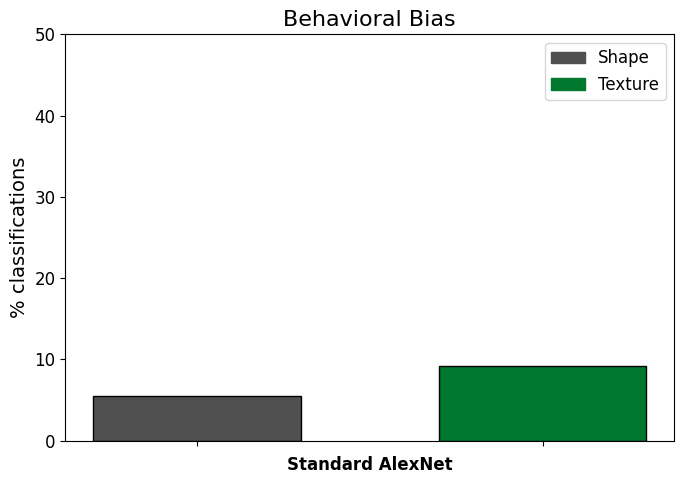

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ast
import os

# --- Configuration & Styling ---
DPI = 300
plt.rcParams.update({"font.family": "sans-serif", "font.size": 12})
plt.rcParams.update({"axes.labelsize": 14, "axes.titlesize": 16})

# Color palette from the original study
STANDARD_RED = np.array([168, 14, 53]) / 255
BIOMIMETIC_BLUE = np.array([0, 82, 137]) / 255

# --- Helper Functions ---

def load_and_parse_results(file_path):
    """Loads CSV and ensures data is accessible as lists."""
    df = pd.read_csv(file_path, index_col=0)
    # Convert string "[s, o, t]" to actual lists if they are strings
    def parse_cell(val):
        if isinstance(val, str):
            return ast.literal_eval(val)
        return val
    return df.applymap(parse_cell)

# --- Figure Plotting Functions ---

def plot_fig_1_top(res_pd, regimen_key, regimen_name, save_path=None):
    """
    Generates Figure 2B: Texture vs Shape Barplot.
    Shows overall classification behavior at baseline (ablation 0).
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    count_types = ["Shape", "Other", "Texture"]
    colors = [np.array([80, 80, 80])/255, np.array([0, 82, 190])/255, np.array([0, 120, 45])/255]

    # Extract baseline ablation 0 data for the regimen
    col_name = f"color_{regimen_key}_ablation_0"
    if col_name not in res_pd.columns:
        print(f"Column {col_name} not found.")
        return

    summary = res_pd[col_name]
    totals = np.zeros(3)
    for val in summary.values:
        totals += np.array(val)

    # Normalize to percentages
    summary_pct = totals / np.sum(totals)

    # Plot bars (excluding 'Other' from the standard bar view to match paper style if desired)
    # Here we plot Shape (index 0) and Texture (index 2)
    x = np.array([0, 1])
    bar_values = [summary_pct[0], summary_pct[2]]
    bar_labels = [count_types[0], count_types[2]]
    bar_colors = [colors[0], colors[2]]

    # 1. Use numeric positions for bars instead of labels to make clearing easier
    x_pos = [0, 1]
    ax.bar(x_pos, bar_values, color=bar_colors, edgecolor='black', width=0.6)

    # 2. Remove individual bar labels from the x-axis
    ax.set_xticks(x_pos) # Set positions first
    ax.set_xticklabels([]) # Then clear the labels

    # 3. Add the regimen name as a single centered x-label
    ax.set_xlabel(regimen_name, fontsize=12, fontweight='bold')

    # Create manual legend handles
    shape_patch = mpatches.Patch(color=colors[0], label='Shape')
    texture_patch = mpatches.Patch(color=colors[2], label='Texture')
    ax.legend(handles=[shape_patch, texture_patch], loc='upper right')

    ax.set_ylabel("% classifications")
    ax.set_ylim([0, 0.5])
    ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
    ax.set_yticklabels([0, 10, 20, 30, 40, 50])
    ax.set_title(f"Behavioral Bias")

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=DPI)
    plt.show()

def plot_fig_2c(res_pd, regimen_key, regimen_name, save_path=None):
    """
    Generates Figure 2C: Category-wise Shape/Texture Ratio.
    Shows which specific categories are most biased.
    """
    col_name = f"color_{regimen_key}_ablation_0"
    summary = res_pd[col_name]

    ratios = {}
    for cat, val in summary.items():
        shape, _, texture = val
        if (shape + texture) > 0:
            ratios[cat.capitalize()] = shape / (shape + texture)
        else:
            ratios[cat.capitalize()] = 0

    # Sort categories by ratio for visualization
    sorted_ratios = dict(sorted(ratios.items(), key=lambda item: item[1]))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)

    y_pos = np.arange(len(sorted_ratios))
    ax.scatter(sorted_ratios.values(), y_pos, color=STANDARD_RED, s=100, marker='|', linewidth=3)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_ratios.keys())
    ax.set_xlim([-0.05, 1.05])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels([0, 25, 50, 75, 100])
    ax.set_xlabel("Shape-based vs. Texture-based correct decisions (%)")
    ax.set_title(f"Category Bias: {regimen_name}")

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=DPI)
    plt.show()

def plot_fig_2de(res_pd, regimen_key, regimen_name, save_path=None):
    """
    Generates Figure 2DE: Texture-Shape Ablation Curves.
    Shows how bias changes as filters are removed.
    """
    ranking_indices = ["color", "color_reverse"]
    ranking_names = ["Low-color Ablation", "High-color Ablation"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = [np.array([80, 80, 80])/255, np.array([0, 120, 45])/255] # Shape, Texture

    num_ablations = 48

    for i, (rank_idx, title) in enumerate(zip(ranking_indices, ranking_names)):
        ax = axes[i]
        shape_curve = []
        texture_curve = []

        # Calculate totals for each ablation step
        for k in range(num_ablations + 1):
            col_name = f"{rank_idx}_{regimen_key}_ablation_{k}"
            if col_name not in res_pd.columns: continue

            step_totals = np.zeros(3)
            for val in res_pd[col_name].values:
                step_totals += np.array(val)

            # Normalize by baseline total to see relative performance drop
            baseline_total = np.sum(np.array(res_pd[f"{rank_idx}_{regimen_key}_ablation_0"].iloc[0])) * len(res_pd)
            # Actually, normalize by the current step's total to match paper if preferred
            # Here we use total images at baseline as the denominator
            den = np.sum(np.array(res_pd[f"{rank_idx}_{regimen_key}_ablation_0"].sum()))

            shape_curve.append(step_totals[0] / den)
            texture_curve.append(step_totals[2] / den)

        ax.plot(range(len(shape_curve)), shape_curve, label="Shape", color=colors[0], linewidth=3)
        ax.plot(range(len(texture_curve)), texture_curve, label="Texture", color=colors[1], linewidth=3)

        ax.set_ylim([0, 0.4])
        ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4])
        ax.set_yticklabels([0, 10, 20, 30, 40])
        ax.set_xlabel("% RFs ablated")
        ax.set_ylabel("Total classifications (%)")
        ax.set_title(title)
        ax.legend()

    plt.suptitle(f"Ablation Analysis: {regimen_name}", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_path: plt.savefig(save_path, dpi=DPI)
    plt.show()

# --- Execution Example ---

if __name__ == "__main__":
    PATH = "/content/drive/MyDrive/colab_results/biomimetic_training/evaluation_results.csv"

    if os.path.exists(PATH):
        data = load_and_parse_results(PATH)

        # 'regimen_key' must match the string used in your CSV column names (e.g., 'standard_alexnet')
        reg_key = "standard_alexnet"
        reg_name = "Standard AlexNet"

        plot_fig_1_top(data, reg_key, reg_name, "fig_1_top.png")
        # plot_fig_2c(data, reg_key, reg_name, "fig_2c.png")
        # plot_fig_2de(data, reg_key, reg_name, "fig_2de.png")
    else:
        print("Results file not found. Check your Drive path.")